<a href="https://colab.research.google.com/github/lakithav/social-media-ad-audience-segmentation/blob/main/social_media_ad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import numpy as np
import pandas as pd

In [25]:
path = '/content/drive/MyDrive/DataSets/ad_campaign_data.csv'
data = pd.read_csv(path)

In [26]:
data.head(2)

,user_id,age,gender,location,device_type,ad_id,ad_category,impressions,clicks,conversions,...,tfidf_11,tfidf_12,tfidf_13,tfidf_14,tfidf_15,tfidf_16,tfidf_17,tfidf_18,tfidf_19,tfidf_20
0,U25795,45,0,2,2,A77161,2,2460,1223,1,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.57735,0.0,0.000000
1,U10860,29,0,0,2,A41167,1,162,117,1,...,0.0,0.0,0.0,0.0,0.0,0.447214,0.0,0.00000,0.0,0.447214


In [10]:
data.shape

(100000, 35)

In [4]:
data.columns

Index(['user_id', 'age', 'gender', 'location', 'device_type', 'ad_id',
       'ad_category', 'impressions', 'clicks', 'conversions',
       'engagement_duration', 'interaction_timestamps',
       'previous_interaction_score', 'sentiment_score', 'tfidf_0', 'tfidf_1',
       'tfidf_2', 'tfidf_3', 'tfidf_4', 'tfidf_5', 'tfidf_6', 'tfidf_7',
       'tfidf_8', 'tfidf_9', 'tfidf_10', 'tfidf_11', 'tfidf_12', 'tfidf_13',
       'tfidf_14', 'tfidf_15', 'tfidf_16', 'tfidf_17', 'tfidf_18', 'tfidf_19',
       'tfidf_20'],
      dtype='object')

In [5]:
data.head(5)

,user_id,age,gender,location,device_type,ad_id,ad_category,impressions,clicks,conversions,...,tfidf_11,tfidf_12,tfidf_13,tfidf_14,tfidf_15,tfidf_16,tfidf_17,tfidf_18,tfidf_19,tfidf_20
0,U25795,45,0,2,2,A77161,2,2460,1223,1,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.57735,0.0,0.000000
1,U10860,29,0,0,2,A41167,1,162,117,1,...,0.0,0.0,0.0,0.0,0.0,0.447214,0.0,0.00000,0.0,0.447214
2,U86820,59,0,1,2,A55186,1,3648,554,1,...,0.0,0.5,0.5,0.0,0.0,0.000000,0.0,0.00000,0.0,0.000000
3,U64886,47,0,1,2,A59722,4,648,259,1,...,0.0,0.5,0.5,0.0,0.0,0.000000,0.0,0.00000,0.0,0.000000
4,U16265,36,1,0,0,A38955,2,3598,1860,1,...,0.0,0.5,0.5,0.0,0.0,0.000000,0.0,0.00000,0.0,0.000000


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   user_id                     100000 non-null  object 
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  int64  
 3   location                    100000 non-null  int64  
 4   device_type                 100000 non-null  int64  
 5   ad_id                       100000 non-null  object 
 6   ad_category                 100000 non-null  int64  
 7   impressions                 100000 non-null  int64  
 8   clicks                      100000 non-null  int64  
 9   conversions                 100000 non-null  int64  
 10  engagement_duration         100000 non-null  float64
 11  interaction_timestamps      100000 non-null  object 
 12  previous_interaction_score  100000 non-null  float64
 13  sentiment_score

In [6]:
data['engagement_duration']

,engagement_duration
0,95.867210
1,83.940891
2,87.167593
3,74.662671
4,104.902438
...,...
99995,62.854375
99996,107.514450
99997,72.162469
99998,116.356859


In [7]:
data['interaction_timestamps']

,interaction_timestamps
0,2025-04-09 11:00:25.813760
1,2025-04-09 11:00:25.813760
2,2025-04-09 11:00:25.813760
3,2025-04-01 11:00:25.813760
4,2025-03-28 11:00:25.813760
...,...
99995,2025-03-24 11:00:26.824391
99996,2025-03-16 11:00:26.824391
99997,2025-03-28 11:00:26.824391
99998,2025-04-01 11:00:26.824391


In [10]:
min_sentiment = data['sentiment_score'].min()
max_sentiment = data['sentiment_score'].max()
print(f"Minimum sentiment score: {min_sentiment}")
print(f"Maximum sentiment score: {max_sentiment}")

Minimum sentiment score: -0.999985028206523
Maximum sentiment score: 0.9999802603701105


In [9]:
data['sentiment_score']

,sentiment_score
0,0.252749
1,0.763779
2,0.284641
3,0.848291
4,-0.299957
...,...
99995,0.012167
99996,-0.057010
99997,-0.637613
99998,0.045955


In [11]:
data.isnull().sum()

,0
user_id,0
age,0
gender,0
location,0
device_type,0
ad_id,0
ad_category,0
impressions,0
clicks,0
conversions,0


In [11]:
data.head(2)

,user_id,age,gender,location,device_type,ad_id,ad_category,impressions,clicks,conversions,...,tfidf_11,tfidf_12,tfidf_13,tfidf_14,tfidf_15,tfidf_16,tfidf_17,tfidf_18,tfidf_19,tfidf_20
0,U25795,45,0,2,2,A77161,2,2460,1223,1,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.57735,0.0,0.000000
1,U10860,29,0,0,2,A41167,1,162,117,1,...,0.0,0.0,0.0,0.0,0.0,0.447214,0.0,0.00000,0.0,0.447214


In [4]:
data["gender"].value_counts()

,count
gender,
0,50068
1,49932


In [5]:
data["device_type"].value_counts()

,count
device_type,
2,33473
1,33307
0,33220


In [6]:
data["ad_category"].value_counts()

,count
ad_category,
0,20214
3,20053
2,19973
4,19948
1,19812


In [8]:
data.filter(like="tfidf").head()

,tfidf_0,tfidf_1,tfidf_2,tfidf_3,tfidf_4,tfidf_5,tfidf_6,tfidf_7,tfidf_8,tfidf_9,...,tfidf_11,tfidf_12,tfidf_13,tfidf_14,tfidf_15,tfidf_16,tfidf_17,tfidf_18,tfidf_19,tfidf_20
0,0.000000,0.0,0.000000,0.57735,0.0,0.0,0.57735,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.57735,0.0,0.000000
1,0.447214,0.0,0.447214,0.00000,0.0,0.0,0.00000,0.0,0.0,0.447214,...,0.0,0.0,0.0,0.0,0.0,0.447214,0.0,0.00000,0.0,0.447214
2,0.000000,0.0,0.000000,0.00000,0.5,0.0,0.00000,0.0,0.5,0.000000,...,0.0,0.5,0.5,0.0,0.0,0.000000,0.0,0.00000,0.0,0.000000
3,0.000000,0.0,0.000000,0.00000,0.5,0.0,0.00000,0.0,0.5,0.000000,...,0.0,0.5,0.5,0.0,0.0,0.000000,0.0,0.00000,0.0,0.000000
4,0.000000,0.0,0.000000,0.00000,0.5,0.0,0.00000,0.0,0.5,0.000000,...,0.0,0.5,0.5,0.0,0.0,0.000000,0.0,0.00000,0.0,0.000000


In [27]:
data = data.drop(["user_id","ad_id","interaction_timestamps"], axis= 1)

In [13]:
data.shape

(100000, 32)

In [14]:
X = data

In [15]:
X.shape

(100000, 32)

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
X_scaled[:5]

array([[ 2.97961595e-01, -9.98640924e-01,  5.93928227e-04,
         1.22141092e+00,  2.05505116e-03, -3.54356846e-02,
        -3.06078141e-02,  3.37172005e-01,  1.00569772e+00,
         9.06019485e-01,  4.35792117e-01, -5.00859228e-01,
        -4.97811532e-01, -5.00859228e-01,  1.99931276e+00,
        -5.02639249e-01, -4.98515181e-01,  1.99931276e+00,
        -4.97811532e-01, -5.02639249e-01, -5.00859228e-01,
        -4.98515181e-01, -4.97811532e-01, -5.02639249e-01,
        -5.02639249e-01, -4.98515181e-01, -4.97811532e-01,
        -5.00859228e-01, -4.98515181e-01,  1.99931276e+00,
        -4.98515181e-01, -5.00859228e-01],
       [-8.82622018e-01, -9.98640924e-01, -1.41352090e+00,
         1.22141092e+00, -7.04148098e-01, -1.63586027e+00,
        -1.03232445e+00,  3.37172005e-01,  6.46693550e-01,
         1.24529918e+00,  1.31977127e+00,  1.99656898e+00,
        -4.97811532e-01,  1.99656898e+00, -5.00171869e-01,
        -5.02639249e-01, -4.98515181e-01, -5.00171869e-01,
        -4.97

In [19]:
X_scaled.shape

(100000, 32)

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate Inertia for Different K

In [30]:
inertia = []

k_values = range(1,11)

for k in k_values:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

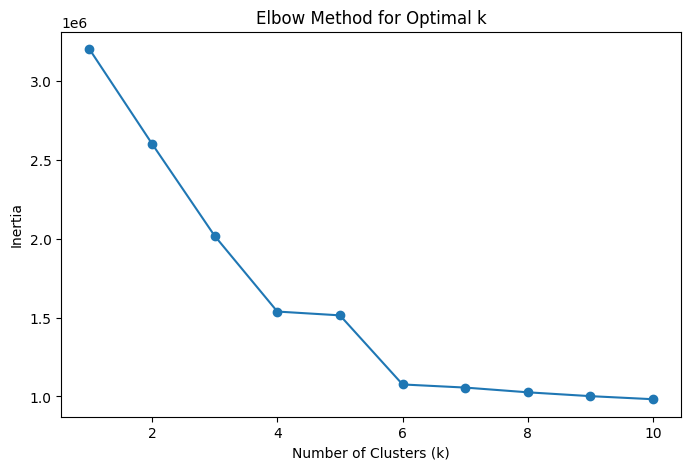

In [31]:
plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")

plt.show()

In [37]:
from sklearn.metrics import silhouette_score

In [40]:
silhouette_scores = []
# Silhouette score is not defined for k=1, so we start from 2
k_values_silhouette = range(2, 11)

for k in k_values_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

print("Silhouette Scores:", silhouette_scores)

Silhouette Scores: [np.float64(0.21671293506030836), np.float64(0.3067436988371893), np.float64(0.37114259254991017), np.float64(0.44370601354790523), np.float64(0.3756270380830622), np.float64(0.3048672135459324), np.float64(0.24259086979795197), np.float64(0.16759871097383547), np.float64(0.17201694147353025)]


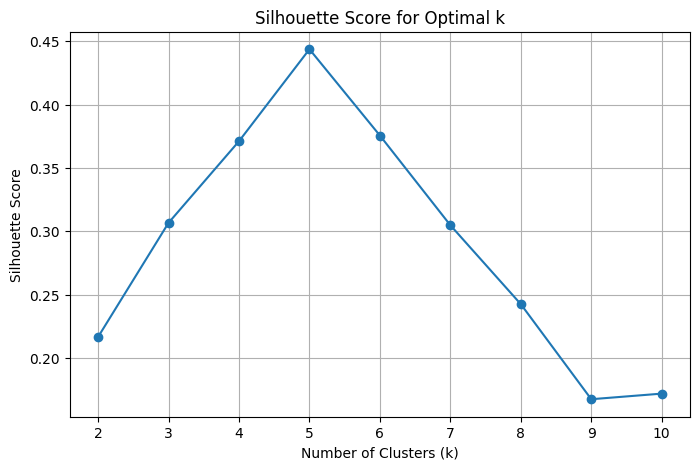

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(k_values_silhouette, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal k")
plt.xticks(k_values_silhouette)
plt.grid(True)
plt.show()

In [42]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [43]:
data["cluster"] = clusters

In [44]:
data.head()

,age,gender,location,device_type,ad_category,impressions,clicks,conversions,engagement_duration,previous_interaction_score,...,tfidf_12,tfidf_13,tfidf_14,tfidf_15,tfidf_16,tfidf_17,tfidf_18,tfidf_19,tfidf_20,cluster
0,45,0,2,2,2,2460,1223,1,95.867210,0.761317,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.57735,0.0,0.000000,3
1,29,0,0,2,1,162,117,1,83.940891,0.859270,...,0.0,0.0,0.0,0.0,0.447214,0.0,0.00000,0.0,0.447214,2
2,59,0,1,2,1,3648,554,1,87.167593,0.773835,...,0.5,0.5,0.0,0.0,0.000000,0.0,0.00000,0.0,0.000000,3
3,47,0,1,2,4,648,259,1,74.662671,0.002448,...,0.5,0.5,0.0,0.0,0.000000,0.0,0.00000,0.0,0.000000,3
4,36,1,0,0,2,3598,1860,1,104.902438,0.996071,...,0.5,0.5,0.0,0.0,0.000000,0.0,0.00000,0.0,0.000000,3


In [45]:
data["cluster"].value_counts()

,count
cluster,
3,40180
2,20055
0,19905
1,19860


In [46]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=data.drop("cluster", axis=1).columns
)

centers

,age,gender,location,device_type,ad_category,impressions,clicks,conversions,engagement_duration,previous_interaction_score,...,tfidf_11,tfidf_12,tfidf_13,tfidf_14,tfidf_15,tfidf_16,tfidf_17,tfidf_18,tfidf_19,tfidf_20
0,0.001288,-0.004618,-0.000791,0.002931,-0.005892,0.002563,0.007206,-0.000846,0.009017,-0.003105,...,-0.497812,-0.502639,-0.502639,2.005957,-0.497812,-0.500859,2.005957,-0.500172,2.005957,-0.500859
1,-0.002910,-0.002265,0.000131,-0.008092,0.000953,0.004810,-0.000851,-0.000115,0.010197,-0.000626,...,2.008792,-0.502639,-0.502639,-0.498515,2.008792,-0.500859,-0.498515,-0.500172,-0.498515,-0.500859
2,-0.003156,-0.001083,-0.001768,0.004168,0.005858,-0.004168,-0.008030,0.000035,-0.009701,-0.000815,...,-0.497812,-0.502639,-0.502639,-0.498515,-0.497812,1.996569,-0.498515,-0.500172,-0.498515,1.996569
3,0.002375,0.003948,0.001210,0.000468,-0.000476,-0.001567,0.000859,0.000458,-0.004665,0.002254,...,-0.497812,0.748330,0.748330,-0.498515,-0.497812,-0.500859,-0.498515,0.744656,-0.498515,-0.500859


In [48]:
cluster_summary = data.groupby("cluster").mean()

cluster_summary

,age,gender,location,device_type,ad_category,impressions,clicks,conversions,engagement_duration,previous_interaction_score,...,tfidf_11,tfidf_12,tfidf_13,tfidf_14,tfidf_15,tfidf_16,tfidf_17,tfidf_18,tfidf_19,tfidf_20
cluster,,,,,,,,,,,,,,,,,,,,,
0,40.979302,0.497011,1.998041,1.004923,1.988747,2514.560663,1264.750163,0.897664,62.756934,0.498844,...,0.0,0.000000,0.000000,0.447214,0.0,0.000000,0.447214,0.00000,0.447214,0.000000
1,40.922407,0.498187,1.999345,0.995921,1.998439,2517.788016,1255.854683,0.897885,62.796110,0.499560,...,0.5,0.000000,0.000000,0.000000,0.5,0.000000,0.000000,0.00000,0.000000,0.000000
2,40.919073,0.498778,1.996659,1.005934,2.005385,2504.896884,1247.928347,0.897931,62.135084,0.499505,...,0.0,0.000000,0.000000,0.000000,0.0,0.447214,0.000000,0.00000,0.000000,0.447214
3,40.994027,0.501294,2.000871,1.002912,1.996416,2508.630986,1257.742509,0.898059,62.302399,0.500391,...,0.0,0.250983,0.250983,0.000000,0.0,0.000000,0.000000,0.28754,0.000000,0.000000


In [49]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [51]:
pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])
pca_df["cluster"] = clusters

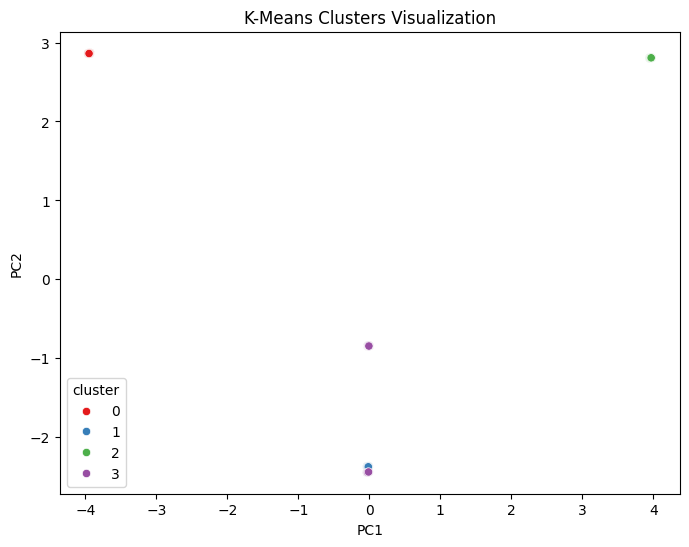

In [52]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="cluster",
    data=pca_df,
    palette="Set1"
)
plt.title("K-Means Clusters Visualization")
plt.show()

In [53]:
sample_data = X_scaled[:5000]

In [54]:
data["cluster"].value_counts()

,count
cluster,
3,40180
2,20055
0,19905
1,19860


In [55]:
cluster_summary

,age,gender,location,device_type,ad_category,impressions,clicks,conversions,engagement_duration,previous_interaction_score,...,tfidf_11,tfidf_12,tfidf_13,tfidf_14,tfidf_15,tfidf_16,tfidf_17,tfidf_18,tfidf_19,tfidf_20
cluster,,,,,,,,,,,,,,,,,,,,,
0,40.979302,0.497011,1.998041,1.004923,1.988747,2514.560663,1264.750163,0.897664,62.756934,0.498844,...,0.0,0.000000,0.000000,0.447214,0.0,0.000000,0.447214,0.00000,0.447214,0.000000
1,40.922407,0.498187,1.999345,0.995921,1.998439,2517.788016,1255.854683,0.897885,62.796110,0.499560,...,0.5,0.000000,0.000000,0.000000,0.5,0.000000,0.000000,0.00000,0.000000,0.000000
2,40.919073,0.498778,1.996659,1.005934,2.005385,2504.896884,1247.928347,0.897931,62.135084,0.499505,...,0.0,0.000000,0.000000,0.000000,0.0,0.447214,0.000000,0.00000,0.000000,0.447214
3,40.994027,0.501294,2.000871,1.002912,1.996416,2508.630986,1257.742509,0.898059,62.302399,0.500391,...,0.0,0.250983,0.250983,0.000000,0.0,0.000000,0.000000,0.28754,0.000000,0.000000


In [56]:
cols_to_drop = [col for col in data.columns if "tfidf" in col]
data_clean = data.drop(cols_to_drop, axis=1)

In [57]:
data_clean.columns

Index(['age', 'gender', 'location', 'device_type', 'ad_category',
       'impressions', 'clicks', 'conversions', 'engagement_duration',
       'previous_interaction_score', 'sentiment_score', 'cluster'],
      dtype='object')

In [58]:
data_clean = data_clean.drop("cluster",axis = 1)

In [59]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_clean)

In [60]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
data_clean["cluster"] = clusters

In [61]:
cluster_summary = data_clean.groupby("cluster").mean()
cluster_summary

,age,gender,location,device_type,ad_category,impressions,clicks,conversions,engagement_duration,previous_interaction_score,sentiment_score
cluster,,,,,,,,,,,
0,40.977359,0.193606,1.989609,1.003906,1.986195,1550.172937,305.747497,0.612864,62.847072,0.496661,-0.002541
1,40.995271,1.000000,2.000415,0.997387,2.011118,1426.298183,645.222019,1.000000,62.270502,0.499348,-0.001197
2,40.948655,0.000000,2.022704,1.003645,2.012776,3374.760424,1924.367471,1.000000,62.371674,0.500666,0.006691
3,40.921529,1.000000,1.977125,1.005212,1.972829,3794.258096,2250.487235,1.000000,62.297990,0.502831,-0.000734


In [62]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [63]:
pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])
pca_df["cluster"] = clusters

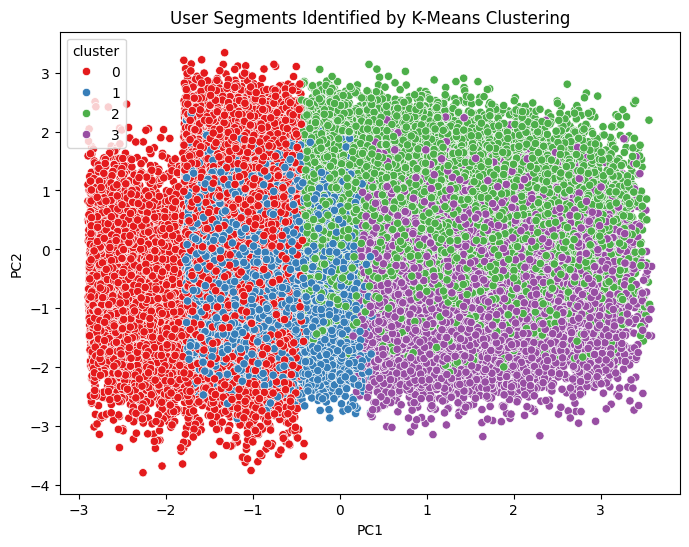

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="cluster",
    data=pca_df,
    palette="Set1"
)

plt.title("User Segments Identified by K-Means Clustering")

plt.show()

# Hierarchical Clustering

In [66]:
sample_data = X_scaled[:5000]

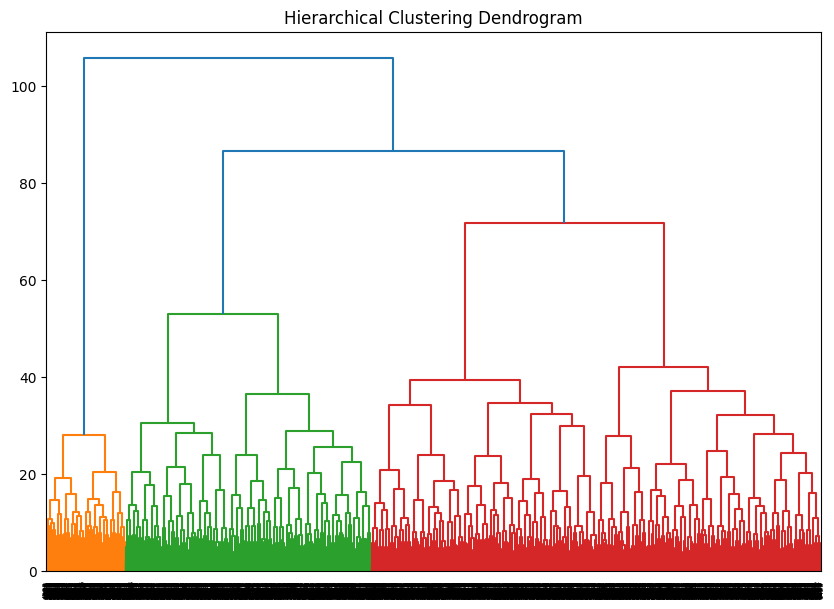

In [67]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(sample_data, method='ward')

plt.figure(figsize=(10,7))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.show()

In [68]:
plt.savefig("denrogram.png")

<Figure size 640x480 with 0 Axes>

In [69]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4)

hc_clusters = hc.fit_predict(sample_data)

In [70]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

sample_pca = pca.fit_transform(sample_data)

In [72]:
import pandas as pd

pca_df = pd.DataFrame(sample_pca, columns=["PC1","PC2"])

pca_df["cluster"] = hc_clusters

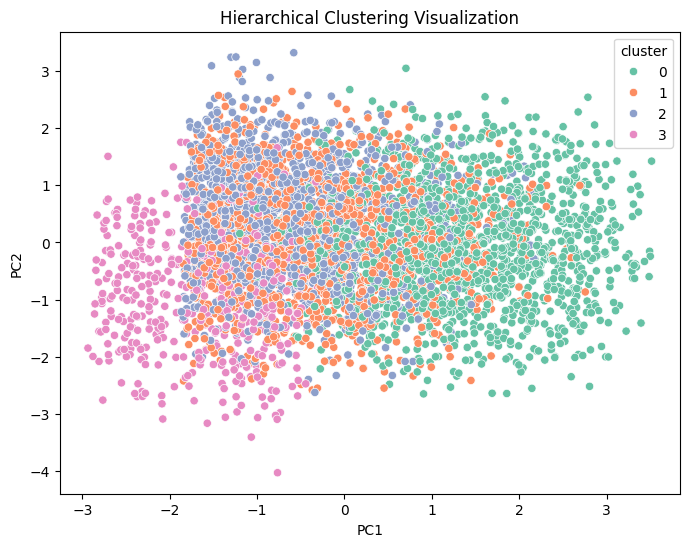

In [73]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="cluster",
    data=pca_df,
    palette="Set2"
)

plt.title("Hierarchical Clustering Visualization")

plt.show()